# 7. Publication bias

**The mistake in one sentence:** positive results get published, negative ones stay in the drawer, so the literature looks better than the truth.

Running on Google Colab? Run the next cell first. It downloads the repo so the data files are there. On your own computer you can skip it.

In [1]:
import os
from pathlib import Path
if not any((p / "src").exists() for p in [Path.cwd(), *Path.cwd().parents]):
    !git clone https://github.com/CS42org/data-make-sins.git
    os.chdir("data-make-sins/notebooks")

In [2]:
import sys
from pathlib import Path
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.append(str(root / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
import dms

dms.style()

## The real case

In January 2008 Erick Turner and colleagues published a study in the New England Journal of Medicine. 74 antidepressant trials had been registered with the US regulator, the FDA. The FDA saw about half as positive. Almost all the positive trials were published. Almost none of the negative trials were, or they were rewritten to sound positive.

In [3]:
t = pd.read_csv(dms.DATA / "turner_2008_trials.csv", index_col="fda_verdict")
t

,trials,published_as_positive,published_as_negative,not_published
fda_verdict,,,,
positive,38,37,0,1
negative_or_questionable,36,11,3,22


In [4]:
published = t.published_as_positive + t.published_as_negative
looks_positive_in_journals = t.published_as_positive.sum() / published.sum()
really_positive = t.loc["positive", "trials"] / t.trials.sum()

print(f"positive in the journals : {looks_positive_in_journals * 100:.0f} %")
print(f"positive in reality      : {really_positive * 100:.0f} %")

positive in the journals : 94 %
positive in reality      : 51 %


In [5]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(["what doctors could read", "what actually happened"],
        [looks_positive_in_journals * 100, really_positive * 100], color=[dms.RED, dms.BLUE], height=0.55)
for y, v in enumerate([looks_positive_in_journals, really_positive]):
    ax.text(v * 100 + 1, y, f"{v * 100:.0f}% positive", va="center", weight="bold")
ax.set_xlim(0, 110); ax.set_xlabel("share of trials that looked positive (%)")
ax.set_title("74 antidepressant trials, Turner et al 2008")
dms.save(fig, "07_turner_2008.png")
plt.show()

## Simulate the drawer

74 trials of a drug with a small real effect. Each trial has its own sample size, so each one gets a noisy estimate. A trial is published if it is significant and positive. A negative trial is published only 14 percent of the time, the rate Turner found.

In [6]:
from scipy.stats import norm

rng = np.random.default_rng(11)
true_effect = 0.25
trials = pd.DataFrame({"n_per_arm": rng.integers(30, 160, size=74)})
trials["standard_error"] = np.sqrt(2 / trials.n_per_arm)
trials["observed_effect"] = true_effect + rng.normal(scale=trials.standard_error)
trials["p_value"] = 2 * (1 - norm.cdf(np.abs(trials.observed_effect / trials.standard_error)))
trials["significant"] = trials.p_value < 0.05
trials["published"] = np.where(trials.significant & (trials.observed_effect > 0), True, rng.random(74) < 0.14)
trials.head()

,n_per_arm,standard_error,observed_effect,p_value,significant,published
0,47,0.206284,0.465129,0.024146,True,True
1,46,0.208514,0.206847,0.321197,False,False
2,133,0.122628,0.150240,0.220510,False,False
3,94,0.145865,0.300710,0.039249,True,True
4,106,0.137361,0.284003,0.038680,True,True


In [7]:
summary = pd.Series({
    "trials run": len(trials),
    "trials published": int(trials.published.sum()),
    "true effect": true_effect,
    "mean effect, all trials": round(trials.observed_effect.mean(), 2),
    "mean effect, published only": round(trials.observed_effect[trials.published].mean(), 2),
})
summary

trials run                     74.00
trials published               40.00
true effect                     0.25
mean effect, all trials         0.26
mean effect, published only     0.34
dtype: float64

The published trials make the drug look stronger than it is. The unpublished ones would have pulled the estimate back down.

## Funnel plot

Each dot is a trial. Big trials sit at the top and are precise. Small trials sit at the bottom and scatter widely. When the small negative ones are missing, the bottom left corner of the funnel is empty.

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
pub, unpub = trials[trials.published], trials[~trials.published]
ax.scatter(pub.observed_effect, pub.n_per_arm, color=dms.BLUE, s=40, label="published")
ax.scatter(unpub.observed_effect, unpub.n_per_arm, facecolors="none", edgecolors=dms.INK2, s=40, label="never published")
ax.axvline(true_effect, color=dms.INK2, lw=1, ls="--")
ax.axvline(pub.observed_effect.mean(), color=dms.RED, lw=2)
ax.text(pub.observed_effect.mean(), 165, "mean of published trials", color=dms.RED, ha="center", fontsize=9)
ax.text(true_effect, 4, "true effect", color=dms.INK2, ha="center", fontsize=9)
ax.set_xlabel("observed effect of the drug"); ax.set_ylabel("people per arm")
ax.set_title("Funnel plot: the missing corner tells the story")
ax.legend(loc="lower right")
dms.save(fig, "07_funnel_plot.png")
plt.show()

## Animated figure

Watch the unpublished trials disappear and the red line, the mean a doctor can see, drift to the right.

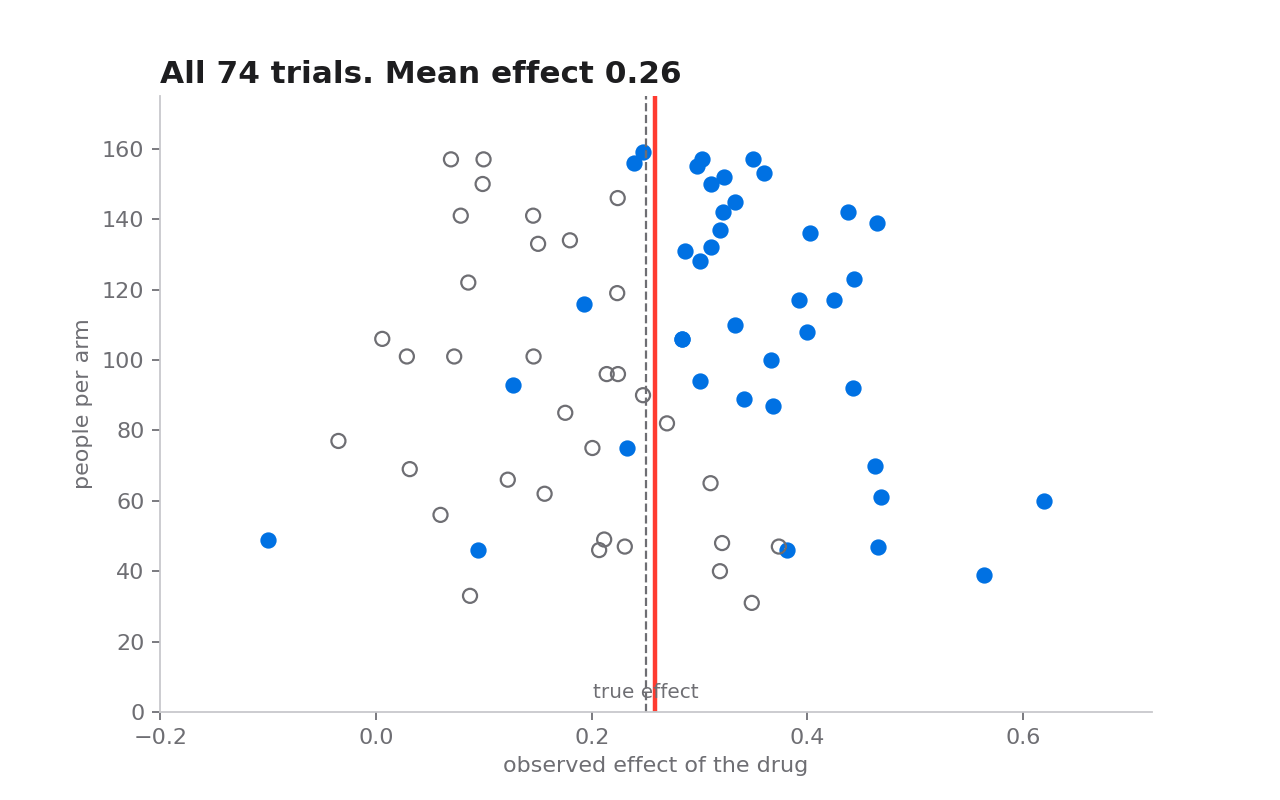

In [9]:
from matplotlib.colors import to_rgb

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(trials.observed_effect.min() - 0.1, trials.observed_effect.max() + 0.1); ax.set_ylim(0, 175)
ax.set_xlabel("observed effect of the drug"); ax.set_ylabel("people per arm")
ax.axvline(true_effect, color=dms.INK2, lw=1, ls="--")
ax.text(true_effect, 4, "true effect", color=dms.INK2, ha="center", fontsize=9)
pub_pts = ax.scatter(pub.observed_effect, pub.n_per_arm, color=dms.BLUE, s=40)
unpub_pts = ax.scatter(unpub.observed_effect, unpub.n_per_arm, facecolors="none", edgecolors=dms.INK2, s=40)
mean_line = ax.axvline(trials.observed_effect.mean(), color=dms.RED, lw=2)
title = ax.set_title("")
order = unpub.sort_values("observed_effect").index
hold = 10

def update(i):
    if i < hold:
        title.set_text(f"All {len(trials)} trials. Mean effect {trials.observed_effect.mean():.2f}")
        return
    k = min(i - hold, len(order))
    gone = order[:k]
    remaining = trials.drop(gone)
    edge = [(*to_rgb(dms.INK2), 0.0 if idx in gone else 1.0) for idx in unpub.index]
    unpub_pts.set_edgecolor(edge)
    m = remaining.observed_effect.mean()
    mean_line.set_xdata([m, m])
    title.set_text(f"{k} negative trials stay in the drawer. Mean a doctor sees: {m:.2f}")
    return unpub_pts, mean_line, title

anim = FuncAnimation(fig, update, frames=hold + len(order) + 12, interval=180)
gif = dms.FIG / "07_file_drawer.gif"
anim.save(gif, writer=PillowWriter(fps=5))
plt.close(fig)
display(Image(filename=str(gif)))

## Better method

Register every trial before it starts, then count all of them at the end, published or not. A funnel plot shows the gap where the missing studies should be. Cochrane needed four and a half years to get the full Tamiflu data from the maker, and the drug turned out to do much less than the published papers said.

## Ask this

What did not get published?